## <center> Machine Learning from Scratch at ETH Zurich
## <center> 8. Linear Neural Networks
### <center> Zhaorui Gong &nbsp; 宫兆瑞

## 8.1 线性神经网络实现线性回归 -- 从零开始
### 8.1.1 生成数据集

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [3]:
def synthetic_data(w, b, n):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (n, len(w)))
    y = torch.mv(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape(-1, 1)  # y改成列向量，只有1列

# synthetic_data(torch.arange(1,10.0).reshape(3,3), np.arange(1,4.0), 3)

In [5]:
true_w = torch.tensor([2.0, -4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([-0.6978,  1.6794]) 
label: tensor([-3.9241])


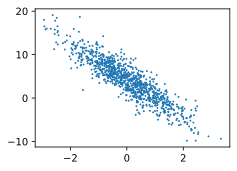

In [7]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)

### 8.1.2 数据集分批读取

In [10]:
# Data Loader 数据读取
# batch training 思想：每次抽取一批量的小样本，并使用它们来更新模型。
def data_iter(batch_size, features, labels):
    n = len(features)
    indices = list(range(n))
    random.shuffle(indices)
    for i in range(0, n, batch_size): # 随机打乱后，间隔b个取indices
        batch_indices = torch.tensor(indices[i: min(i + batch_size, n)])
        yield features[batch_indices], labels[batch_indices]  # yield返回一个generator对象，但只能iterable一次

batch_size = 10
for X, y in data_iter(batch_size, features, labels):    # yield 不产生内存，对比直接实例化一个list作为batch
    print(X, '\n', y.reshape(1, -1))                    # 而这里只是一个dataloader的思想
    break  # 打印一个batch看看

tensor([[-0.1252, -0.3188],
        [-1.2484,  2.2861],
        [-1.3424,  0.3306],
        [-1.1466, -0.6648],
        [ 0.0617,  0.7591],
        [ 1.9395,  2.1011],
        [ 0.0809,  1.3651],
        [-0.0684, -0.3683],
        [ 1.2245, -0.8687],
        [-0.6520, -0.5019]]) 
 tensor([[ 5.2114, -7.4441,  0.1768,  4.5629,  1.2997, -0.3398, -1.1013,  5.5419,
         10.1200,  4.9074]])


### 8.1.3 初始化模型参数与定义模型、损失

In [12]:
# 通常用 N(0, 0.01)来初始化权重w，用0来初始化偏置b。
w = torch.normal(0, 0.01, true_w.shape, requires_grad = True)
b = torch.zeros(1, requires_grad = True)

def linear_model(X, w, b):
    return torch.matmul(X, w) + b

def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape))**2 / 2   # 此处y是1维

### 8.1.4 定义优化算法：SGD

In [14]:
def sgd(params, lr, batch_size):
    with torch.no_grad():  # 反向传播时不需要计算梯度
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

### 8.1.5 训练

理解这段代码至关重要，因为在深度学习中，训练框架将几乎完全重复地出现。在每次iteration中，我们读取一个batch的训练样本，通过模型来获得一组预测。计算完损失后，进行反向传播，储存每个参数的梯度。最后，调用优化算法来更新梯度。

In [16]:
# 超参数设置
lr = 0.03
num_epochs = 3
net = linear_model  # forward
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        y_hat = net(X, w, b)
        l = loss(y_hat, y)
        # 注意此时l.shape = (batch_size, 1)，不是标量，注意对张量求梯度
        v = torch.ones_like(l)
        l.backward(v)
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_loss = loss(net(features, w, b), labels)
        print(f'epoch: {epoch+1}, loss: {float(train_loss.mean()):f}')


epoch: 1, loss: 0.036629
epoch: 2, loss: 0.000127
epoch: 3, loss: 0.000049


In [18]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0002, -0.0002], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0006], grad_fn=<RsubBackward1>)


## 8.2 用现代DL库来简洁实现线性回归
在8.1中我们只用了（1）张量进行数据储存和线性代数运算 （2）通过自动微分来计算梯度。

本节我们将复习Dataloader, Loss, Optimizer和Layers of Neural Networks

### 8.2.1 生成数据集

In [20]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

In [22]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

### 8.2.2 读取数据集
调用框架中现有的API来读取数据。我们将features和labels作为API的参数传递，并通过iterator指定batch_size.

In [24]:
def load_array(data_arrays, batch_size, is_train=True):  # is_train表示是否希望iterator在每个迭代周期(epoch)内打乱数据
    dataset = data.TensorDataset(*data_arrays)   # *data_arrays is to unpack，而不是把features和labels当做一个object。TensorDataset需要传入tensors而非object
    # dataset[0] returns (features[0], labels[0]) 
    # dataset[1] returns (features[1], labels[1])；TensorDataset可理解为pd.Dataframe, 两个数据集的行必须相同
    return data.DataLoader(dataset, batch_size, shuffle=is_train)   # Data_loader 即前面的data_iter, yielding an iterable.

batch_size = 10
data_iter = load_array((features, labels), batch_size)
next(iter(data_iter))

[tensor([[-0.9355,  0.5053],
         [-1.5701, -0.7359],
         [ 1.2811, -0.0965],
         [ 1.2062,  1.6752],
         [ 0.2213, -0.1667],
         [-0.9489,  0.7373],
         [ 0.7621,  0.8138],
         [-0.7839,  0.6444],
         [ 0.1137, -0.1262],
         [-0.7306,  0.9004]]),
 tensor([[ 0.6121],
         [ 3.5617],
         [ 7.0942],
         [ 0.9157],
         [ 5.2086],
         [-0.1938],
         [ 2.9639],
         [ 0.4362],
         [ 4.8465],
         [-0.3345]])]

In [26]:
# 这等价于前面的 iteration，我们尝试一下
for X, y in data_iter:
    print(X, '\n', y)
    break   # 注意每次结果不相同，因为前面shuffle = True. 如果把is_train改成False，那就一样了。

tensor([[-9.4887e-01,  7.3733e-01],
        [ 7.6327e-01, -1.1167e-01],
        [ 4.2780e-02, -3.9296e-01],
        [-5.7556e-01, -1.3228e-01],
        [-6.1372e-04, -5.0627e-01],
        [-8.5994e-01, -2.4633e+00],
        [ 3.8495e-01,  4.2546e-01],
        [-7.9808e-01, -1.0991e+00],
        [ 1.0868e-01,  1.1048e+00],
        [-9.1471e-01, -1.1857e+00]]) 
 tensor([[-0.1938],
        [ 6.0988],
        [ 5.6279],
        [ 3.5005],
        [ 5.9046],
        [10.8487],
        [ 3.5175],
        [ 6.3318],
        [ 0.6661],
        [ 6.4017]])


### 8.2.3 定义模型、初始化参数、损失函数与优化器
对于标准深度学习模型我们只需要关注使用哪些层来构造模型，而不必关注层的实现细节。

模型变量net是Sequantial类的实例，将多隔层串联在一起，前一层输出作为下一层输入。在线性回归中，模型只包含一个fully_connected layer, which means that 每一个输入都通过matrix_vector multiplication得到每一个输出。全连接层用Linear(imput, output)定义.

In [28]:
from torch import nn
net = nn.Sequential(
    nn.Linear(2, 1)
)

In [30]:
# initializing parameters
net[0].weight.data.normal_(0, 0.01)   # 这里自动requires_grad = True，无需手动定义
net[0].bias.data.fill_(0)  # .weight.data用于访问参数attribute，后面的.normal_(), .fill_()用于重写参数

tensor([0.])

In [32]:
# 定义损失函数与优化算法
loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(), lr = 0.03)  # net.parameters表示要优化的参数

### 8.2.4 训练
1. 前向传播并计算损失
2. 反向传播得到梯度
3. 执行优化算法更新参数

In [34]:
num_epochs = 5
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)   # 一次epoch之后，监控loss变化
    print(f'epoch {epoch+1}, loss = {l:f}')

epoch 1, loss = 0.000272
epoch 2, loss = 0.000099
epoch 3, loss = 0.000099
epoch 4, loss = 0.000099
epoch 5, loss = 0.000100


In [36]:
# 与真实参数对比误差
w_hat = net[0].weight.data
b_hat = net[0].bias.data
print('the error of w', true_w - w_hat.reshape(true_w.shape))
print('the error of b', true_b - b_hat)
print("Gradient of w:", net[0].weight.grad)
print("Gradient of b:", net[0].bias.grad)

the error of w tensor([ 0.0006, -0.0001])
the error of b tensor([-0.0009])
Gradient of w: tensor([[-0.0045, -0.0084]])
Gradient of b: tensor([-0.0035])


## 8.3 分类问题、交叉熵损失与Fashion-MNIST数据集
这部分涉及到信息论内容，注意one-hot encoding、交叉熵的理解、softmax求导、与logistic回归的关系等问题

In [38]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

### 8.3.1 读取数据集
我们通过框架中的内置函数把Fashion-MINST数据集下载并读取到内存中，通过ToTensor将图像数据从PIL type变换为32位浮点，并除以255使得所有像素数值都在0-1之间。

该数据集是LeCun 1998手写数字数据集的拓展，由10个类别的图像组成，每个类别train-test大小为6000-1000。

In [40]:
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

In [42]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [44]:
mnist_train[0][0].shape  # 每个图像高度h*宽度w = 28*28，灰度图像所以通道数=1.

torch.Size([1, 28, 28])

In [46]:
def get_fashion_mnist_labels(labels):  #@save
    '''返回该数据集的文本标签'''
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    '''可视化样本'''
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:  # PIL
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'shirt'}>,
       <Axes: title={'center': 'coat'}>], dtype=object)

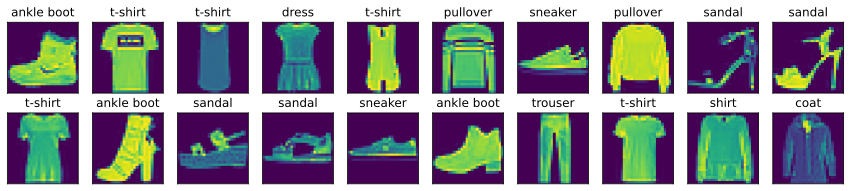

In [48]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=20)))
show_images(X.reshape(20, 28, 28), 2, 10, titles=get_fashion_mnist_labels(y))

### 8.3.2 读取小批量
回顾一下，每次迭代中数据加载器每次都会读取一小批量数据，大小为batch_size。通过内置数据迭代器，我们可以随机打乱所有样本。

In [50]:
batch_size = 256
def get_dataloader_workers():
    return 4   # 使用4个进程来读取数据

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers())

In [52]:
timer = d2l.Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.3f} sec'

'11.033 sec'

### 8.3.3 整合所有组件

In [53]:
def load_data_fashion_mnist(batch_size, resize=None):
    '''下载Fashion-MNIST数据集，然后将其加载到内存中'''
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    return(data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers()), 
           data.DataLoader(mnist_test, batch_size, shuffle=True, num_workers=get_dataloader_workers()))

In [54]:
train_iter, test_iter = load_data_fashion_mnist(batch_size=32, resize=64)  # 调整图像大小
for X, y in train_iter:  # 打印一个数据点
    print(X.shape, X.dtype, y.shape, y.dtype)
    print(y)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
tensor([8, 3, 1, 1, 9, 6, 3, 8, 0, 0, 6, 7, 3, 2, 1, 7, 9, 6, 7, 6, 8, 7, 9, 6,
        1, 0, 1, 2, 7, 4, 9, 0])


## 8.4 Softmax回归 - 从零开始
### 8.4.1 初始化模型参数

In [114]:
import torch
from IPython import display
from d2l import torch as d2l

In [116]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [118]:
num_inputs = 784  # 展平28*28图像
num_outputs = 10  # 共10种类别
w = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

### 8.4.2 定义softmax操作与线性网络模型
由于softmax分母需要求和，我们复习对不同维度进行sum的结果

$$
\text{softmax}(X)_{ij} = \frac{\exp(X_{ij})}{\sum_{k}\exp(X_{ik})}
$$
$$
\text{softmax}(x)_{j} = \frac{\exp(x_j)}{\sum_{k=1}^{d}\exp(x_{k})}
$$

In [121]:
X = torch.tensor([[1.0, 2, 3], [4.0, 5, 6]])
print(X.sum(axis=0), X.sum(axis=0, keepdim=True))   # 如果不keepdim，则降维，返回一个shape(3,)的一维张量
print(X.sum(1), X.sum(1, keepdim=True))

tensor([5., 7., 9.]) tensor([[5., 7., 9.]])
tensor([ 6., 15.]) tensor([[ 6.],
        [15.]])


In [123]:
def softmax(X):   # 参数X是任意维度的tensors
    X_exp = torch.exp(X)
    partition = X_exp.sum(axis=1, keepdim=True)
    return X_exp / partition  # 这里应用了广播机制

X = torch.normal(0, 1, (3, 4))
X_prob = softmax(X)
print(X, '\n', X_prob, '\n', X_prob.sum(1))
# 潜在的问题：exp会使矩阵中非常大/小的值造成数值外溢，但我们没有预防这一点

tensor([[ 0.9635, -0.8300, -0.6617,  1.8037],
        [ 1.0573, -0.0112, -1.1969,  0.5482],
        [-0.5416, -0.7265, -1.0946, -0.8089]]) 
 tensor([[0.2717, 0.0452, 0.0535, 0.6296],
        [0.4879, 0.1676, 0.0512, 0.2933],
        [0.3153, 0.2620, 0.1814, 0.2413]]) 
 tensor([1.0000, 1.0000, 1.0000])


In [125]:
def net(X):
    X_ = X.reshape((-1, w.shape[0]))  # 只要列和w的行对齐就行
    return softmax(torch.matmul(X_, w) + b)

### 8.4.3 定义交叉熵损失函数
$$
\text{CE Loss}(\hat{y}, y) = - \sum_{i=1}^{k}y_i \log{\hat{y}_i}
$$

In [128]:
def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])

y = torch.tensor([0, 2])   # 第一个样本的正确label是0，第二个是2
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
print(y_hat[[0, 1], y])    # 相对应，0.1和0.5是两个样本的正确概率。这里语法前面的[0, 1] index表示这两个样本
cross_entropy(y_hat, y)

tensor([0.1000, 0.5000])


tensor([2.3026, 0.6931])

### 8.4.4 模型评估：分类精度

In [131]:
def accuracy(y_hat, y):
    '''计算预测正确的数量'''
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:  # 注意y_hat是矩阵
        y_hat = y_hat.argmax(axis = 1)  # 取每列最大概率的index，这样的得数就是预测类别了
    cmp = y_hat == y
    return float(cmp.sum())

accuracy(y_hat, y) / len(y)

0.5

In [133]:
class Accumulator:  #@save
    '''在n个变量上累加'''
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):  # *args打包任意参数
        # Take every single argument passed into this method (no matter how many there are) and bundle them all up into a single tuple named 'args'.
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [135]:
def evaluate_accuracy(net, data_iter):   # 对任意数据迭代器data_iter可访问的数据集，我们都可以评估在任意模型net的精度
    '''计算在指定数据集上的精度'''
    if isinstance(net, torch.nn.Module):
        net.eval()   # 评估模式
    enum = Accumulator(2)  # 预测对了的、总预测数
    with torch.no_grad():
        for X, y in data_iter:
            enum.add(accuracy(net(X), y), y.numel())
    return enum[0] / enum.data[1]    # 这里调用写不写attribute都一样

In [137]:
evaluate_accuracy(net, test_iter)  # 此时net的权重是初始值，因此近乎随机猜测。10个类别盲猜，精度约为0.1。

0.0356

### 8.4.5 训练
在开始训练前，定义一个在动画中绘制数据的实用类Animator，可以简化剩余部分的代码。

In [139]:
class Animator:  #@save   这部分内容在VS Code中使
    '''绘制数据'''
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None, ylim=None, 
                 xscale='linear', yscale='linear', fmts=('-', 'm--', 'g-.', 'r:'), 
                 nrows=1, ncols=1, figsize=(3.5, 2.5)):
    
    # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 实用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y): 
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if self.X is None:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [140]:
def train_epoch_softmax(net, train_iter, loss, updater):  # updater是更新模型参数的函数，其参数为batch_size
    '''一个epoch内训练模型'''
    if isinstance(net, torch.nn.Module):
        net.train()
    enum = Accumulator(3)  # training loss，# correct predictions, y length
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):   # 实用torch内置优化器
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:   # 用自己定制的优化器
            l.sum().backward()    # 同理，l不是标量
            updater(X.shape[0])   # 传入参数是batch_size
        accu_count = accuracy(y_hat, y)
        enum.add(float(l.sum()), accu_count, y.numel())
    return enum.data[0] / enum.data[2], enum[1] / enum[2]   # average training loss, average accuracy

In [141]:
def train_softmax(net, train_iter, test_iter, loss, num_epochs, updater):
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9], legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_softmax(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch+1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

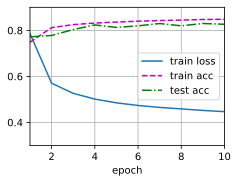

In [142]:
lr = 0.1
def updater(batch_size):
    return d2l.sgd([w, b], lr, batch_size)
    
num_epochs = 10
train_softmax(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

### 8.4.6 预测

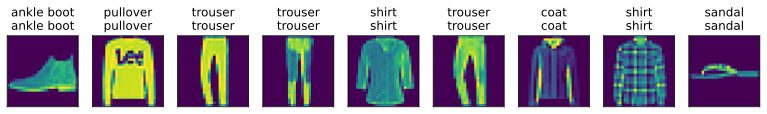

In [155]:
def predict_softmax(net, test_iter, n=6):
    for X, y in test_iter:
        break   # 只为了取第一批X, y
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])
predict_softmax(net, test_iter, n=9)

## 8.5 Softmax回归 - 用现代DL库简洁实现

In [158]:
import torch
from torch import nn
from d2l import torch as d2l

In [163]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
net = nn.Sequential(nn.Flatten(),   # 手动展平图像，输出维度784
                    nn.Linear(784, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)

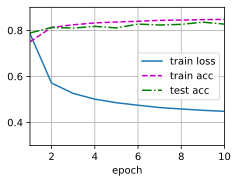

In [170]:
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.1)
num_epochs = 10
train_softmax(net, train_iter, test_iter, loss, num_epochs, trainer)

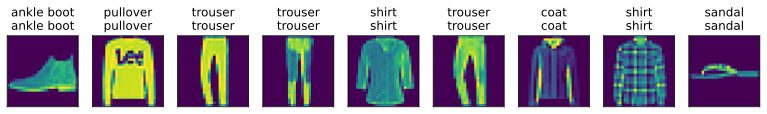

In [172]:
def predict_softmax(net, test_iter, n=6):
    for X, y in test_iter:
        break   # 只为了取第一批X, y
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])
predict_softmax(net, test_iter, n=9)